# Одноканальная и многоканальная СМО M/M/c

Моделирование системы массового обслуживания с экспоненциальными
распределениями интервалов поступления и времени обслуживания.

In [1]:
using DrWatson
@quickactivate "project"
using StableRNGs
using Distributions
using ConcurrentSim
using ResumableFunctions
using DataFrames
using Statistics
using CSV
using Plots

  Activating project at `~/2026-1--study--simulation-modeling/labs/lab07/project`


## Фиксация генератора случайных чисел

In [2]:
rng = StableRNG(123)

StableRNGs.LehmerRNG(state=0x000000000000000000000000000000f7)

## Параметры модели

In [3]:
num_customers = 1000
num_servers = 2

mu = 0.5          # интенсивность обслуживания
lam = 0.9         # интенсивность поступления заявок

0.9

## Распределения

In [4]:
arrival_dist = Exponential(1 / lam)
service_dist = Exponential(1 / mu)

Distributions.Exponential{Float64}(θ=2.0)

## Таблица для логирования событий

In [5]:
log_df = DataFrame(
    id = Int[],
    arrival = Float64[],
    start_service = Float64[],
    finish = Float64[],
    waiting = Float64[],
    service = Float64[],
)

Row,id,arrival,start_service,finish,waiting,service
,Int64,Float64,Float64,Float64,Float64,Float64


## Процесс обслуживания одной заявки

In [6]:
@resumable function customer(
    env::Environment,
    server::Resource,
    id::Int,
    t_a::Float64,
)
    @yield timeout(env, t_a)
    arrival_time = now(env)
    req = request(server)
    @yield req
    service_start = now(env)
    wait_time = service_start - arrival_time
    service_time = rand(rng, service_dist)
    @yield timeout(env, service_time)
    finish_time = now(env)
    @yield unlock(server)
    push!(log_df, (id, arrival_time, service_start, finish_time, wait_time, service_time))
end

customer (generic function with 1 method)

## Создание среды и ресурсов

In [7]:
sim = Simulation()
server = Resource(sim, num_servers)

ConcurrentSim.Resource

## Генерация потока заявок

In [8]:
global arrival_time = 0.0

for i in 1:num_customers
    global arrival_time += rand(rng, arrival_dist)
    @process customer(
        sim,
        server,
        i,
        arrival_time,
    )
end

## Запуск симуляции

In [9]:
run(sim)

## Вывод статистики

In [10]:
println("Среднее время ожидания: ", mean(log_df.waiting))
println("Среднее время обслуживания: ", mean(log_df.service))

Среднее время ожидания: 5.900882801930325
Среднее время обслуживания: 1.9636150889433126


## Сохранение результатов

In [11]:
CSV.write(datadir("mmc_results.csv"), log_df)

"/home/dgavdadaev/2026-1--study--simulation-modeling/labs/lab07/project/data/mmc_results.csv"

## Визуализация

Could not create decoration from factory! Running with no decorations.
Результаты сохранены в data/ и plots/


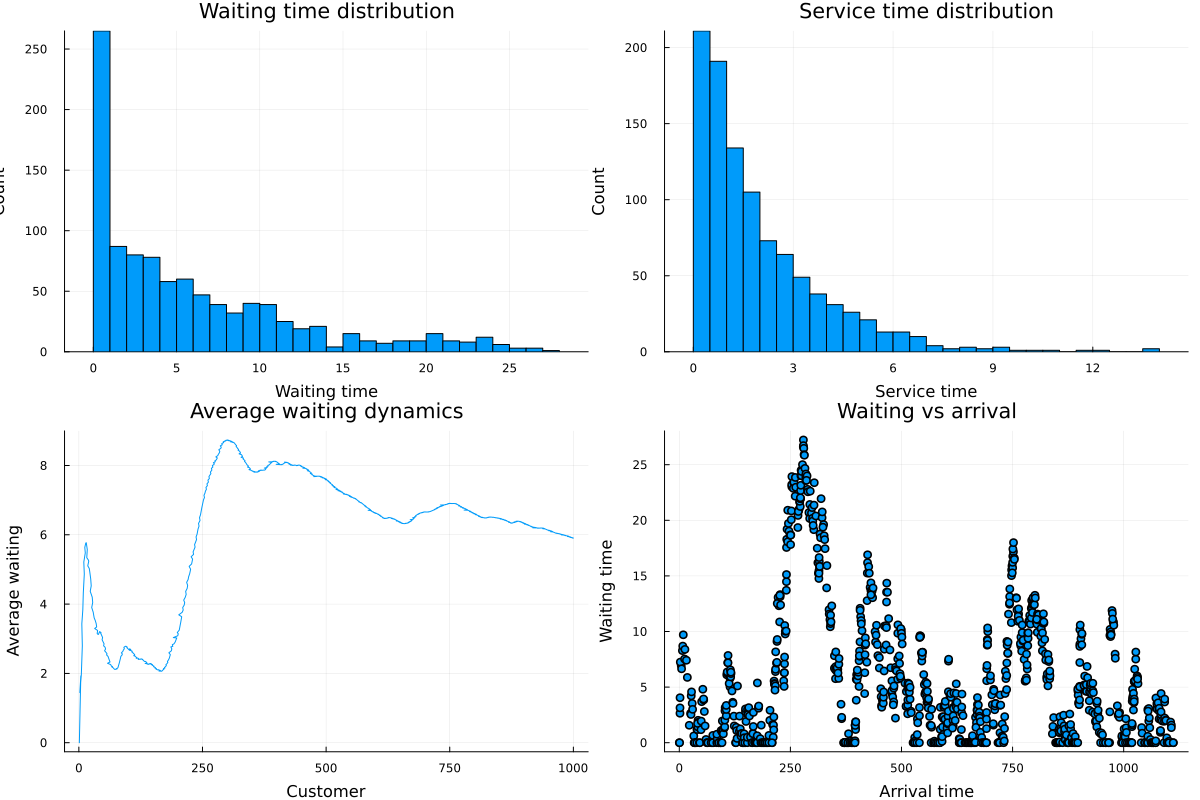

In [12]:
p1 = histogram(log_df.waiting, bins=30, xlabel="Waiting time", ylabel="Count", title="Waiting time distribution", legend=false)
p2 = histogram(log_df.service, bins=30, xlabel="Service time", ylabel="Count", title="Service time distribution", legend=false)
p3 = plot(log_df.id, cumsum(log_df.waiting)./(1:nrow(log_df)), xlabel="Customer", ylabel="Average waiting", title="Average waiting dynamics", legend=false)
p4 = scatter(log_df.arrival, log_df.waiting, xlabel="Arrival time", ylabel="Waiting time", title="Waiting vs arrival", legend=false)

final_plot = plot(p1, p2, p3, p4, layout=(2,2), size=(1200,800))
display(final_plot)
savefig(plotsdir("mmc_plots.png"))

println("Результаты сохранены в data/ и plots/")

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*